# Monte Carlo: LPED half-window `d` vs. TRGB error

Small `d` follows the edge but counts few stars (noisy response); large `d` is stable but smears the
edge. What does that trade-off cost, and can the peak diagnostics flag a bad detection without
knowing the truth?

Every realization is analysed with **all** `d` values, so the comparison is paired. Failed detections
are kept as rows with `success = False` and the exception message.


In [35]:
# source ../.venv/bin/activate

# trzeba uruchomic jupyter lab z tego juz dzialajacego srodowiska


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.optimize import minimize_scalar

from tqdm.auto import tqdm

from trgb_lib import *

print("ok")

ok


In [3]:
# ============================================================
# Simulation parameters
# ============================================================

m_trgb = 10.0

alpha_rgb = 0.30
rgb_range = 3.0
N_rgb_1mag = 200

alpha_agb = 0.20
agb_range = 2.0
N_agb_1mag = round(N_rgb_1mag/5)

photometric_error = 0.03



In [27]:
# Size of the run: how many luminosity functions, and which half-windows each of them is
# analysed with. Every d sees the same LF, so the comparison across d is paired.

N_realizations = 1000

d_values = np.array([0.05,0.10,0.15,0.20,0.25,0.30,0.35,0.40,])

step = 0.01
sigma=0.01

In [28]:
# ============================================================
# Independent random-number streams
# ============================================================

master_seed = random_seed()

master_sequence = np.random.SeedSequence(master_seed)
realization_sequences = master_sequence.spawn(N_realizations)

# ============================================================
# Monte Carlo simulation
# ============================================================

results = []

n_failed = {d: 0 for d in d_values}
n_failed_alpha = 0

for realization, realization_sequence in enumerate(tqdm(realization_sequences, desc="Monte Carlo")):    

    # Independent streams for RGB, AGB and photometric noise
    rgb_sequence, agb_sequence, phot_sequence = (realization_sequence.spawn(3))

    seed_rgb = int(rgb_sequence.generate_state(1, dtype=np.uint32)[0])
    seed_agb = int(agb_sequence.generate_state(1, dtype=np.uint32)[0])
    seed_phot = int(phot_sequence.generate_state(1, dtype=np.uint32)[0])

    # --------------------------------------------------------
    # Generate one luminosity function
    # --------------------------------------------------------

    m_rgb = rgb_lf(m_trgb=m_trgb,alpha=alpha_rgb,m_range=rgb_range,N_1mag=N_rgb_1mag,seed=seed_rgb,)
    m_agb = agb_powerlaw_lf(m_trgb=m_trgb,alpha=alpha_agb,m_range=agb_range,N_agb_1mag=N_agb_1mag,seed=seed_agb,)
    m = np.concatenate((m_rgb,m_agb,))
    m = add_photometric_errors(m,errors=photometric_error,seed=seed_phot,)
    m = np.sort(m)

    # --------------------------------------------------------
    # RGB slope: does not depend on d, so it is fitted once per realization
    # --------------------------------------------------------

    try:

        alpha_mle, alpha_err, res = fit_alpha_mle(m,m1=m_trgb + 0.5,m2=m_trgb + 2.0,)

    except (
        ValueError,
        RuntimeError,
        IndexError,
        ZeroDivisionError,
    ):

        # Every d is built on this slope, so a realization that loses it is dropped whole
        # and is not held against any single d.
        n_failed_alpha += 1
        continue

    # --------------------------------------------------------
    # Apply all d values to the same luminosity function
    # --------------------------------------------------------

    for d in d_values:

        try:

            x_filter, response, counts_bright, counts_faint = local_poisson_filter(m,d=d,alpha=alpha_mle,step=step,sigma=sigma,method="score",)
            trgb_detected, diagnostics = detect_local_peak(x_filter,response,d=d,initial=m_trgb,search_range=0.5,competitor_fraction=0.5)

            trgb_error = trgb_detected - m_trgb


            scale = np.sqrt(0.1)/np.sqrt(d)
            results.append({
                "realization": realization,
                "d": d,
                
                "seed_rgb": seed_rgb,
                "seed_agb": seed_agb,
                "seed_phot": seed_phot,

                "trgb_true": m_trgb,
                "trgb_detected": trgb_detected,
                "trgb_error": trgb_error,
                "absolute_error": abs(trgb_error),

                "peak_height":diagnostics["peak_height"],
                "peak_height_scale":diagnostics["peak_height"]*scale,   # tu raczej powinno byc normalized
                "peak_prominence":diagnostics["peak_prominence"],
                "peak_width":diagnostics["peak_width_half"],
                "peak_flatness":diagnostics["peak_flatness"],
                "sharpness":diagnostics["sharpness"],
                "area_main":diagnostics["area_main"],
                "area_outside_bright":diagnostics["area_outside_bright"],
                "area_outside_faint":diagnostics["area_outside_faint"],
                "area_outside":diagnostics["area_outside"],
                "outside_area_fraction":diagnostics["outside_area_fraction"],
            })

        except (
            ValueError,
            RuntimeError,
            IndexError,
            ZeroDivisionError,
        ):

            # A realization the detector could not handle is dropped, not recorded as a row of
            # NaNs — only the counters below remember it.
            n_failed[d] += 1


# Failures are not spread evenly over d, and dropping them is a selection: a d that fails often
# is left with only the realizations that happened to go well. Hence the breakdown.

print(f"realizations: {N_realizations - n_failed_alpha} usable, {n_failed_alpha} dropped at the slope fit")

print(f"detections: {len(results)} succeeded, {sum(n_failed.values())} failed")

for d in d_values:
    print(f"    d = {d:.2f}: {n_failed[d]:4d} failed")


Monte Carlo:   0%|          | 0/10000 [00:00<?, ?it/s]

realizations: 10000 usable, 0 dropped at the slope fit
detections: 80000 succeeded, 0 failed
    d = 0.05:    0 failed
    d = 0.10:    0 failed
    d = 0.15:    0 failed
    d = 0.20:    0 failed
    d = 0.25:    0 failed
    d = 0.30:    0 failed
    d = 0.35:    0 failed
    d = 0.40:    0 failed


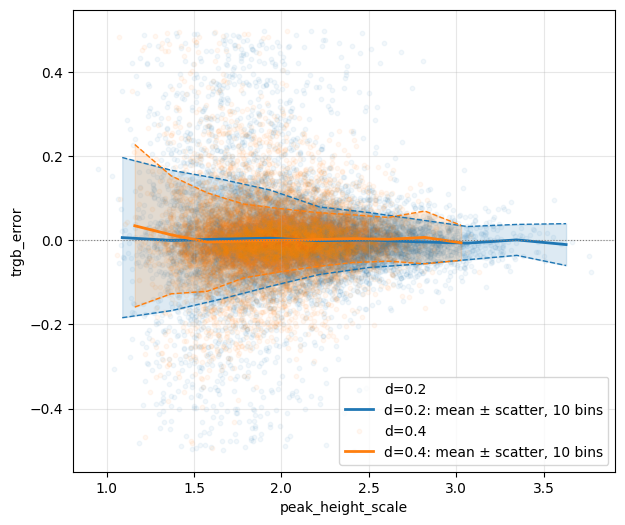

In [34]:
# What goes on the axes. Swap these to plot any other pair of recorded columns —
# everything below works on x and y only.

x_key = "peak_height_scale"


y_key = "trgb_error"
#y_key = "sharpness"


x_label = x_key
y_label = y_key

d_plot = [0.2,0.4]


# Trend of y along x: the range of x is split into equal-width bins, and each bin gives the
# mean of y and how widely it scatters. Bins holding fewer points than min_count are left
# empty instead of pretending to be a measurement.

n_bins = 10
min_count = 3


plt.figure(figsize=(7,6))

for i, d in enumerate(d_plot):

    color = f"C{i}"

    x = np.array([r[x_key] for r in results if r["d"] == d])
    y = np.array([r[y_key] for r in results if r["d"] == d])

    plt.scatter(x, y, s=10, alpha=0.05, color=color, label=f"d={d}")


    # ---------- Mean and scatter of y per bin of x ----------

    edges = np.linspace(x.min(), x.max(), n_bins + 1)

    centers = 0.5 * (edges[:-1] + edges[1:])

    means = np.full(n_bins, np.nan)
    scatters = np.full(n_bins, np.nan)

    for j in range(n_bins):

        # The last bin keeps its right edge, so that the highest point is counted too.
        if j == n_bins - 1:
            in_bin = (x >= edges[j]) & (x <= edges[j + 1])
        else:
            in_bin = (x >= edges[j]) & (x < edges[j + 1])

        if in_bin.sum() >= min_count:
            means[j] = np.mean(y[in_bin])
            scatters[j] = np.std(y[in_bin], ddof=1)


    # ---------- Mark them on the plot ----------

    plt.plot(centers, means, "-", color=color, linewidth=2, label=f"d={d}: mean ± scatter, {n_bins} bins")

    plt.plot(centers, means - scatters, "--", color=color, linewidth=1)
    plt.plot(centers, means + scatters, "--", color=color, linewidth=1)

    plt.fill_between(centers, means - scatters, means + scatters, color=color, alpha=0.15)


plt.axhline(0.0, color="gray", linestyle=":", linewidth=0.8)

plt.xlabel(x_label)
plt.ylabel(y_label)

plt.grid(alpha=0.3)
plt.legend()

#plt.xlim(0,0.4)

plt.show()